# Planteamiento del Problema:

Los depósitos a largo plazo permiten a los bancos retener dinero durante un período de tiempo específico, lo que permite al banco utilizar ese dinero para mejorar sus inversiones. Las campañas de marketing de este producto se basan en llamadas telefónicas. Si un usuario no se encuentra disponible en un momento dado, entonces se le volverá a llamar de nuevo en otro momento.

El banco portugués está teniendo una disminución en sus ingresos, por lo que quieren poder identificar a los clientes existentes que tienen una mayor probabilidad de contratar un depósito a largo plazo. Esto permitirá que el banco centre sus esfuerzos de marketing en esos clientes y evitará perder dinero y tiempo en clientes que probablemente no se suscribirán.

Para abordar este problema crearemos un algoritmo de clasificación que ayude a predecir si un cliente contratará o no un depósito a largo plazo.

# Paso 1: Carga del conjunto de datos:

El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre bank-marketing-campaign-data.csv, y puedes cargarlo en el código directamente desde el siguiente enlace:

https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

total_data = pd.read_csv("/workspaces/machine-learning-python-template/data/raw/bank-marketing-campaign-data.csv", sep=";")
total_data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# Paso 2: Exploración y Limpieza



In [3]:
total_data.shape


(41188, 21)

In [4]:
total_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

- Existen 41.188 filas en este dataset correspondiente a la información de posibles clientes del banco a los que se le puede ofrecer un depositos a largo plazo.
- Ninguna de las 21 columnas cuenta con valores nulos.
- El data set cuanta con 11 variables categoricas y 10 numericas.

# Verificamos que no haya duplicados en el dataset

In [5]:
total_data.duplicated().sum()
np.int64(0)
print("Filas duplicadas exactas:", total_data.duplicated().sum())

Filas duplicadas exactas: 12


In [6]:
total_data = total_data.drop_duplicates()
print(total_data.shape)
total_data.head()

(41176, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# Eliminamos información irrelevante:

En esta ocasión seremos cautelozos y por los momentos solo eliminaremos "duration".

In [7]:
total_data.drop(["duration"], axis=1, inplace= True)
total_data.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# Paso 3: Análisis de variables univariantes

- Análisemos a través de histograma el comportamiento de las 11 variables categoricas.

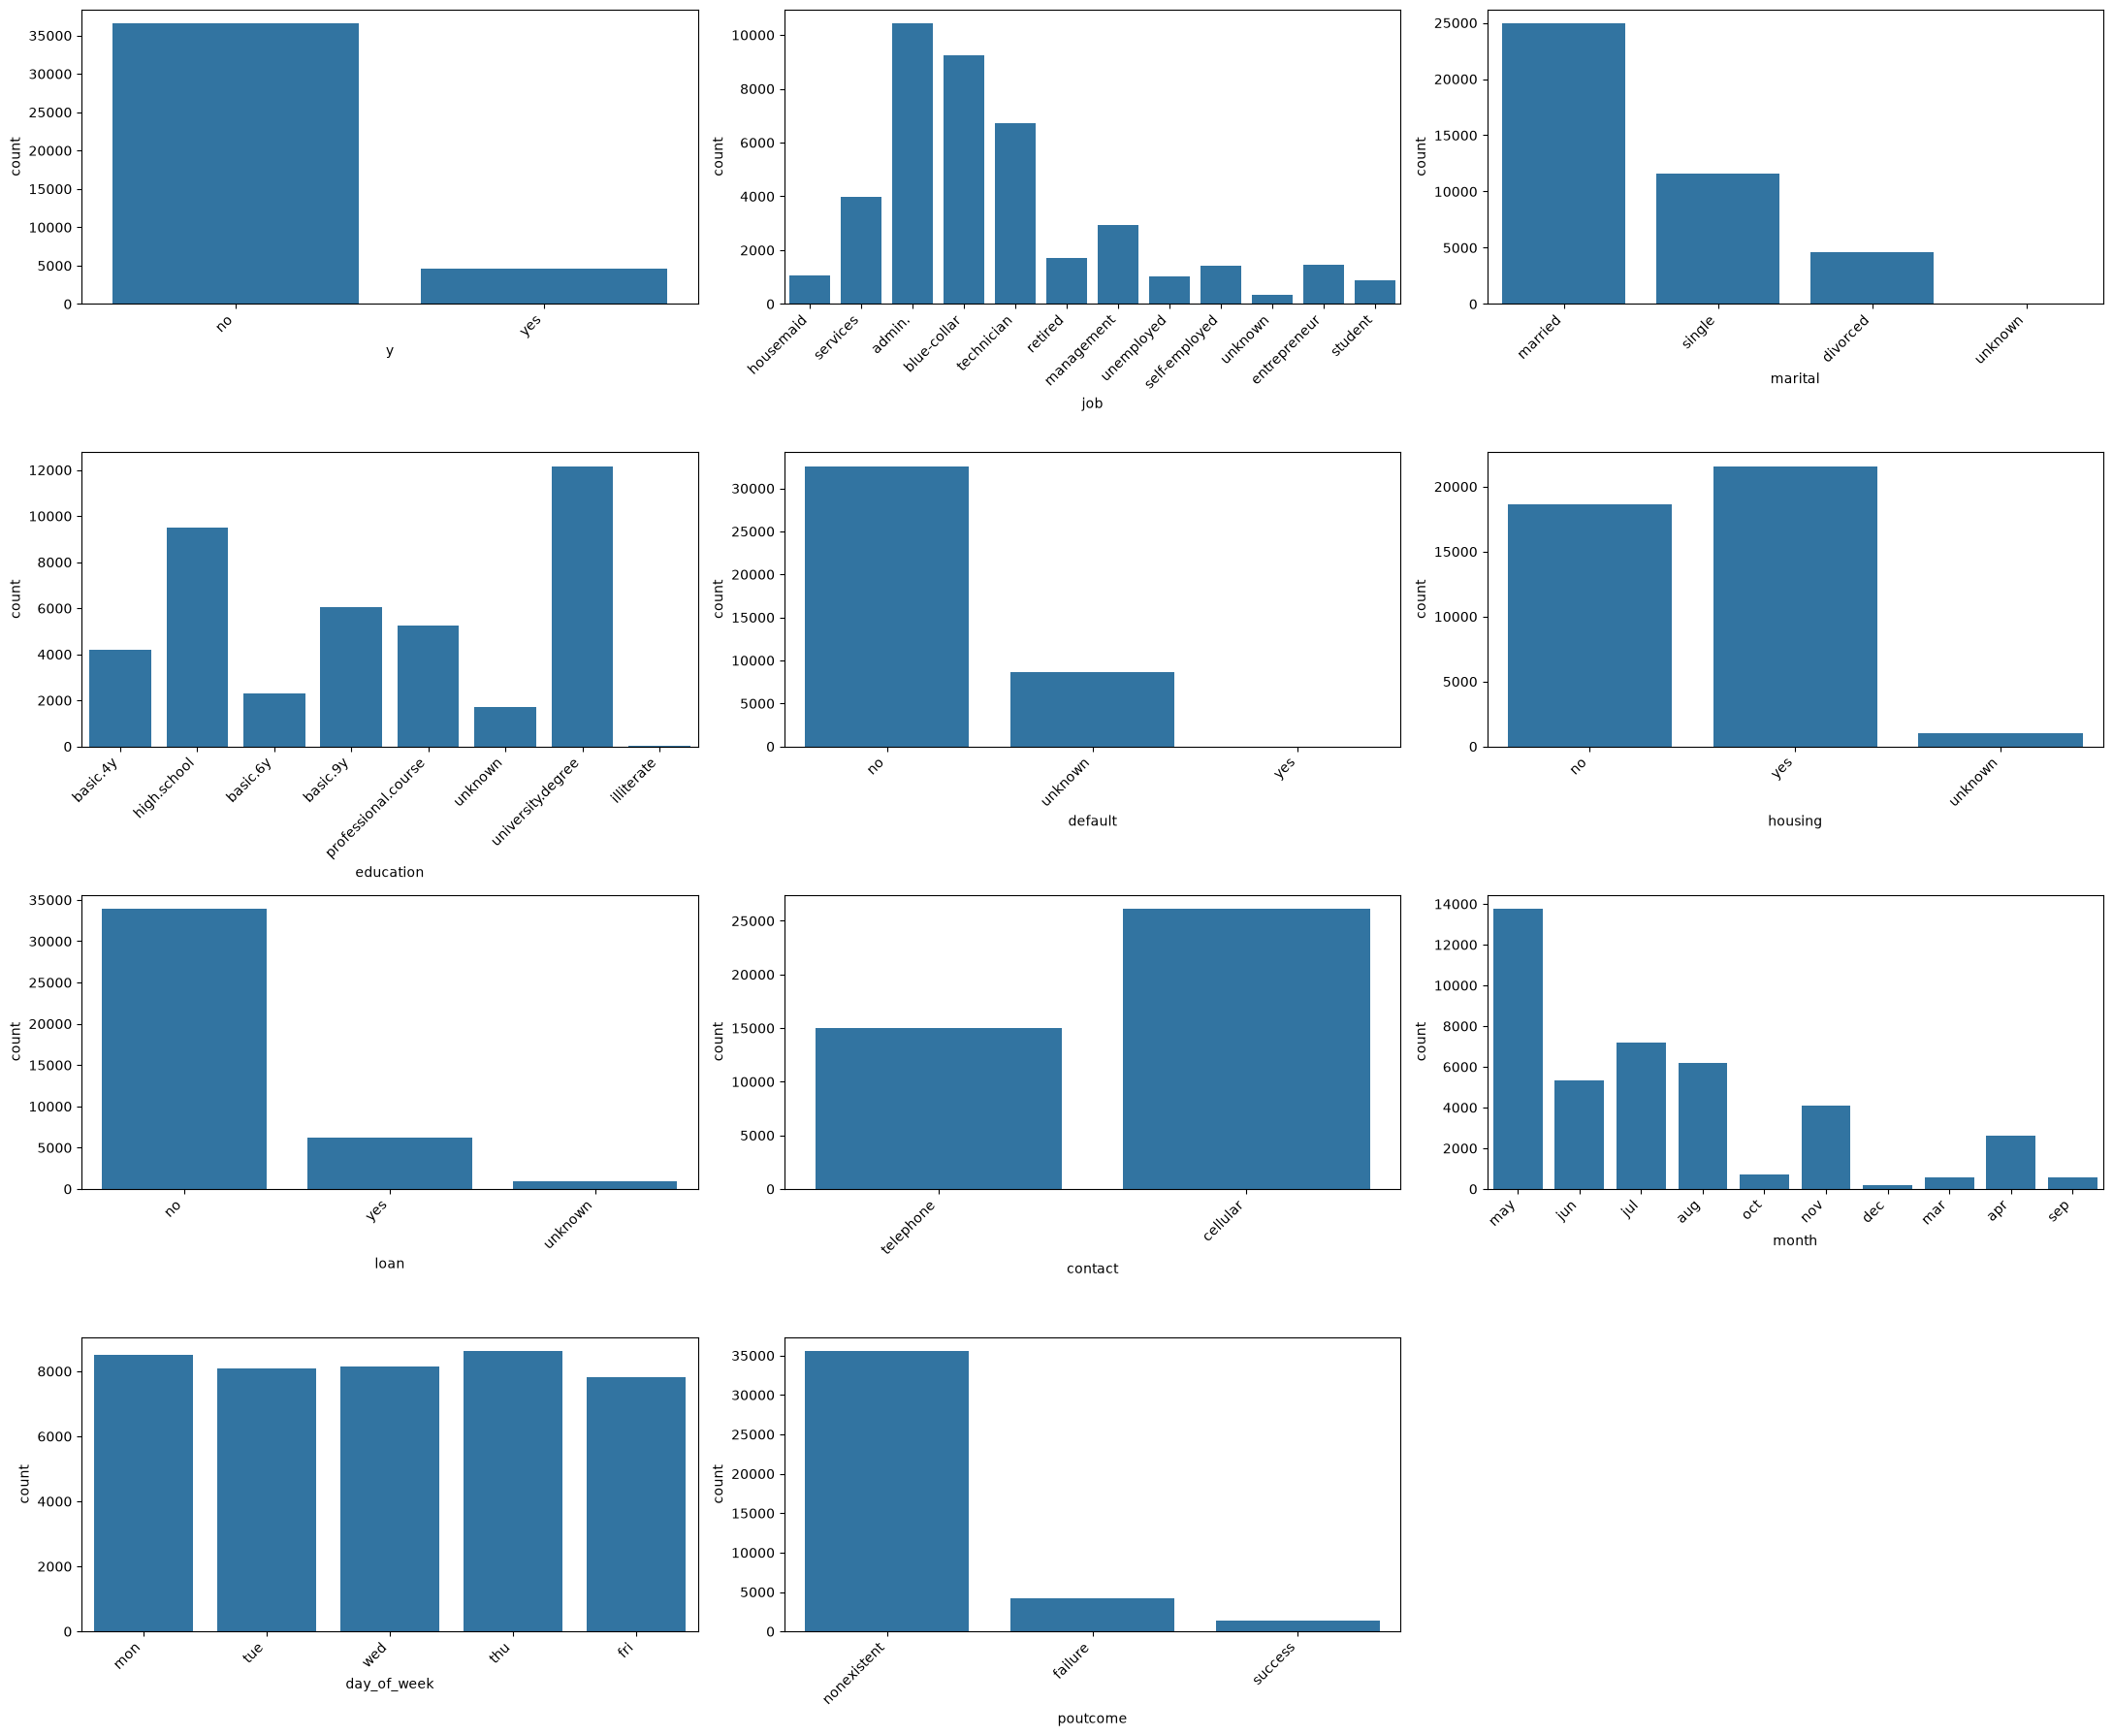

In [8]:
fig, axis = plt.subplots(4, 3, figsize=(22, 18))


def plot_categorical(ax, col):
    sns.countplot(data=total_data, x=col, ax=ax)
    ax.set_title("")
    ax.tick_params(axis='x', rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha('right')


plot_categorical(axis[0, 0], "y")
plot_categorical(axis[0, 1], "job")
plot_categorical(axis[0, 2], "marital")
plot_categorical(axis[1, 0], "education")
plot_categorical(axis[1, 1], "default")
plot_categorical(axis[1, 2], "housing")
plot_categorical(axis[2, 0], "loan")
plot_categorical(axis[2, 1], "contact")
plot_categorical(axis[2, 2], "month")
plot_categorical(axis[3, 0], "day_of_week")
plot_categorical(axis[3, 1], "poutcome")


# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
fig.delaxes(axis[3, 2])
plt.show()

- **Y:** una enorme proporción de clientes rechazó la oferta (no), frente a un porcentaje minoritario que aceptó contratar el depósito a largo plazo (yes), lo cual es el reto principal a tratar al entrenar el modelo de clasificación.

- **Job:** predominan marcadamente los clientes con empleos de tipo administrativo (admin), obreros (blue-collar) y técnicos (technician), mientras que categorías como estudiantes, desempleados o amas de casa tienen una representación minoritaria en las llamadas.

- **Marital:** los casados duplican a los solteros + divorciados.

- **Education:** el nivel educativo más común entre los prospectos es university degree, seguido por el secundario (high.school), seguido por los niveles de educación básica. Hay una presencia muy baja de personas analfabetas (illiterate) o con datos no especificados.

- **Default:** prácticamente la totalidad de los clientes no tienen créditos en impago (la categoría no domina de forma absoluta), encontrándose muy pocos registros en la categoría unknown y un número nulo o despreciable en yes.

- **Housing:** existe una distribución relativamente equilibrada, aunque con una ligera inclinación hacia los clientes que sí poseen un préstamo hipotecario en comparación con los que no lo tienen.

- **Loan:** la inmensa mayoría de los clientes no cuentan con préstamos personales activos; el grupo con créditos de consumo personales es una minoría clara en la cartera analizada.

- **Contact:** el canal de comunicación predominante para realizar las llamadas comerciales es la telefonía celular, superando de manera importante a los contactos por teléfono fijo tradicional.

- **Month:** la actividad de marketing se concentra fuertemente en determinados periodos, destacando mayo (may) con el pico más alto de llamadas, seguido por los meses de verano/otoño, mientras que los meses de enero y febrero no registran actividad.

- **Day_of_week:** las llamadas se distribuyen de forma bastante uniforme de lunes a viernes.

- **Poutcome:** la gran mayoría de los registros se encuentran bajo la categoría nonexistent (clientes que no habían sido contactados en campañas previas), lo que indica que es una base con un alto volumen de prospectos nuevos o no trabajados anteriormente.

## Análisis sobre variantes numéricas:




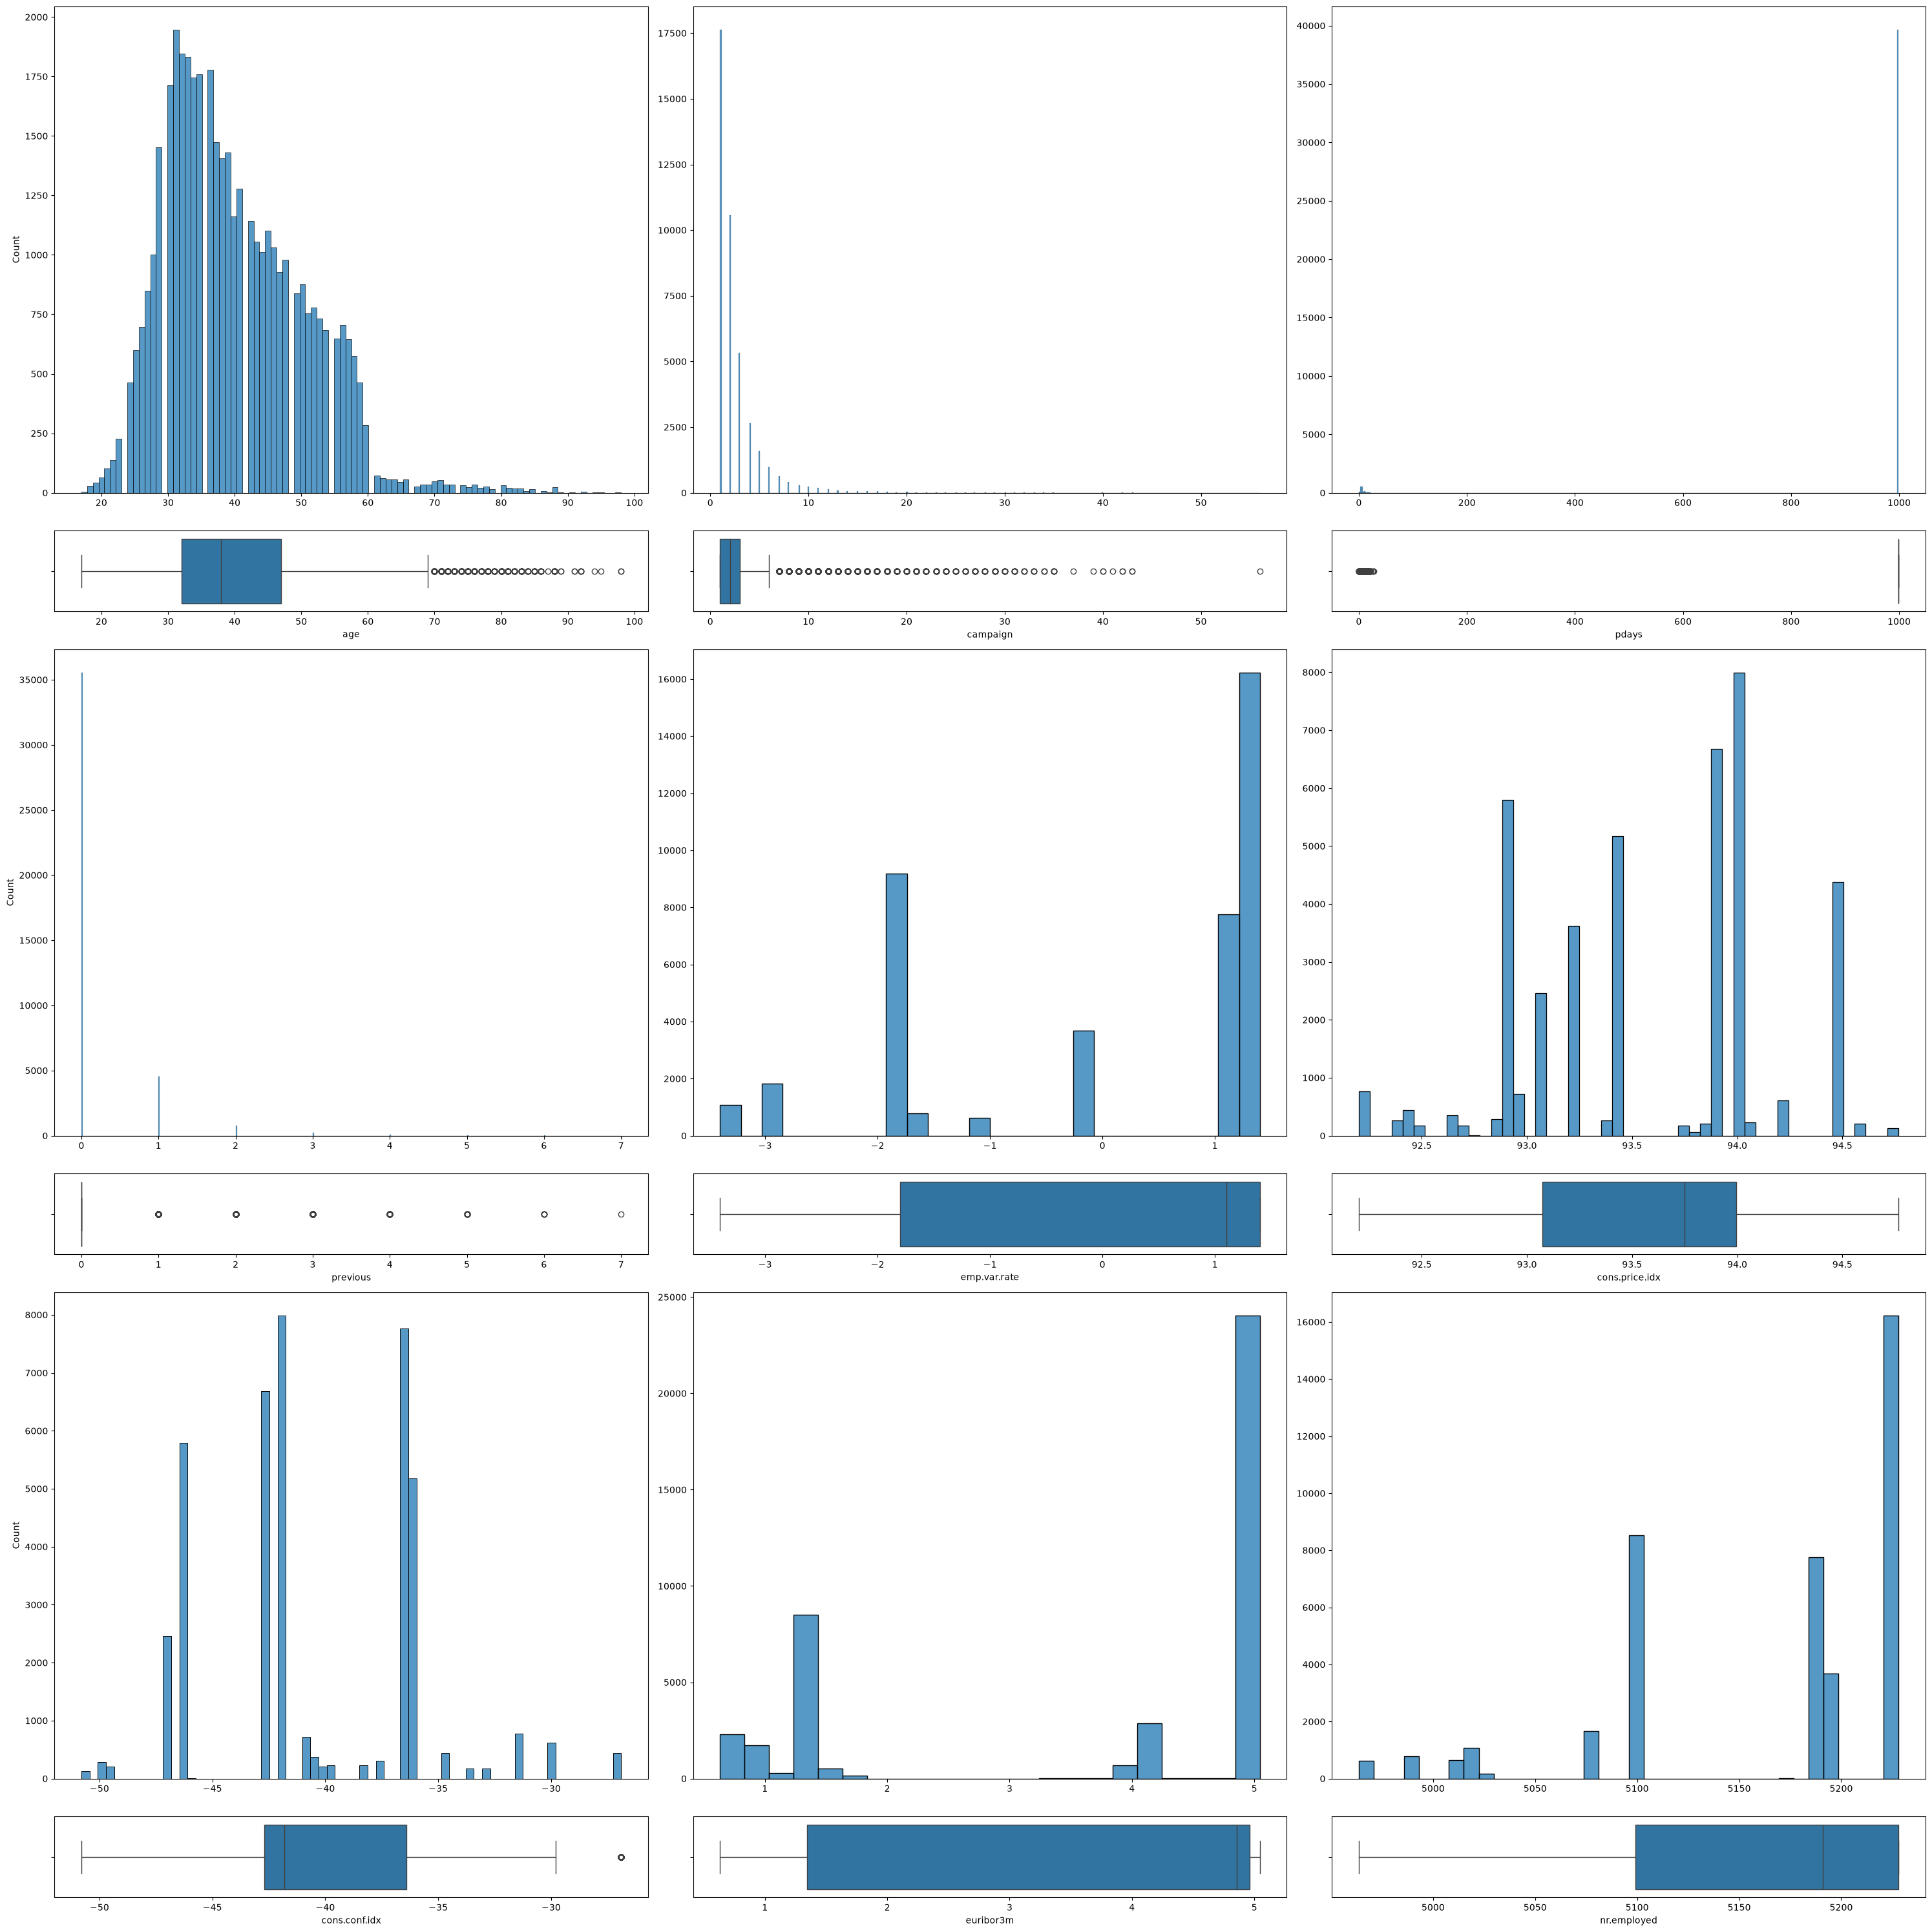

In [9]:
fig, axis = plt.subplots(6, 3, figsize = (30, 30), gridspec_kw={'height_ratios': [6, 1, 6, 1, 6, 1]})

# Crear una figura múltiple con histogramas y diagramas de caja
sns.histplot(ax = axis[0, 0], data = total_data, x = "age").set(xlabel = None)
sns.boxplot(ax = axis[1, 0], data = total_data, x = "age")
sns.histplot(ax = axis[0, 1], data = total_data, x = "campaign").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 1], data = total_data, x = "campaign")
sns.histplot(ax = axis[0, 2], data = total_data, x = "pdays").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 2], data = total_data, x = "pdays")
sns.histplot(ax = axis[2, 0], data = total_data, x = "previous").set(xlabel = None)
sns.boxplot(ax = axis[3, 0], data = total_data, x = "previous")
sns.histplot(ax = axis[2, 1], data = total_data, x = "emp.var.rate").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3, 1], data = total_data, x = "emp.var.rate")
sns.histplot(ax = axis[2, 2], data = total_data, x = "cons.price.idx").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3, 2], data = total_data, x = "cons.price.idx")
sns.histplot(ax = axis[4, 0], data = total_data, x = "cons.conf.idx").set(xlabel = None)
sns.boxplot(ax = axis[5, 0], data = total_data, x = "cons.conf.idx")
sns.histplot(ax = axis[4, 1], data = total_data, x = "euribor3m").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[5, 1], data = total_data, x = "euribor3m")
sns.histplot(ax = axis[4, 2], data = total_data, x = "nr.employed").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[5, 2], data = total_data, x = "nr.employed")

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

- **Presencia dispar de valores atípicos (outliers):** Mientras que variables como la edad (age) muestran algunos valores atípicos hacia los extremos superiores (clientes de mayor edad), otras variables como el número de contactos en la campaña (campaign) o contactos previos (previous) concentran una gran cantidad de puntos aislados hacia la derecha, lo que indica distribuciones con colas largas (muchos valores sesgados hacia pocos registros con frecuencias muy altas).

- **Comportamientos asimétricos:** La mayoría de las variables numéricas no siguen una distribución normal simétrica. Por ejemplo, campaign y pdays están fuertemente sesgadas; en pdays, el valor 999 (que representa a clientes que nunca antes habían sido contactados) domina de forma absoluta, separándose visualmente del resto de la distribución.

- **Estabilidad y agrupación en indicadores macroeconómicos:** Indicadores como el índice de precios al consumidor (cons.price.idx), la tasa de variación del empleo (emp.var.rate) o el número de empleados (nr.employed) muestran aglomeraciones muy marcadas en ciertos rangos o niveles discretos, reflejando las condiciones económicas específicas de los periodos en los que se realizaron las llamadas de la campaña.

## Análisis numérico - numérico

- Antes de realizar el análisis numérico - numérico en función de nuestra variable objetivo (y) debemos factorizarla y agregar una nueva columna en nuestro data set

In [10]:
set(list(total_data.y))

{'no', 'yes'}

In [11]:
total_data.y

0         no
1         no
2         no
3         no
4         no
        ... 
41183    yes
41184     no
41185     no
41186    yes
41187     no
Name: y, Length: 41176, dtype: str

In [12]:
total_data["y_n"] = pd.factorize(total_data.y)[0] # Transforma no -> 0 y yes -> 1
total_data[["y_n", "y"]]

,y_n,y
0,0,no
1,0,no
2,0,no
3,0,no
4,0,no
...,...,...
41183,1,yes
41184,0,no
41185,0,no
41186,1,yes


In [13]:
# Nos tenemos que guardar las reglas de que no es 0 y yes es 1
import json

y_transformation_rules = {row["y"]: row["y_n"] for index, row in total_data[["y_n", "y"]].drop_duplicates().iterrows()}
with open("./y_transformation_rules.json", "w") as f:
  json.dump(y_transformation_rules, f)

## Ahora si procedemos con los gráficos de análisis numérico - numérico

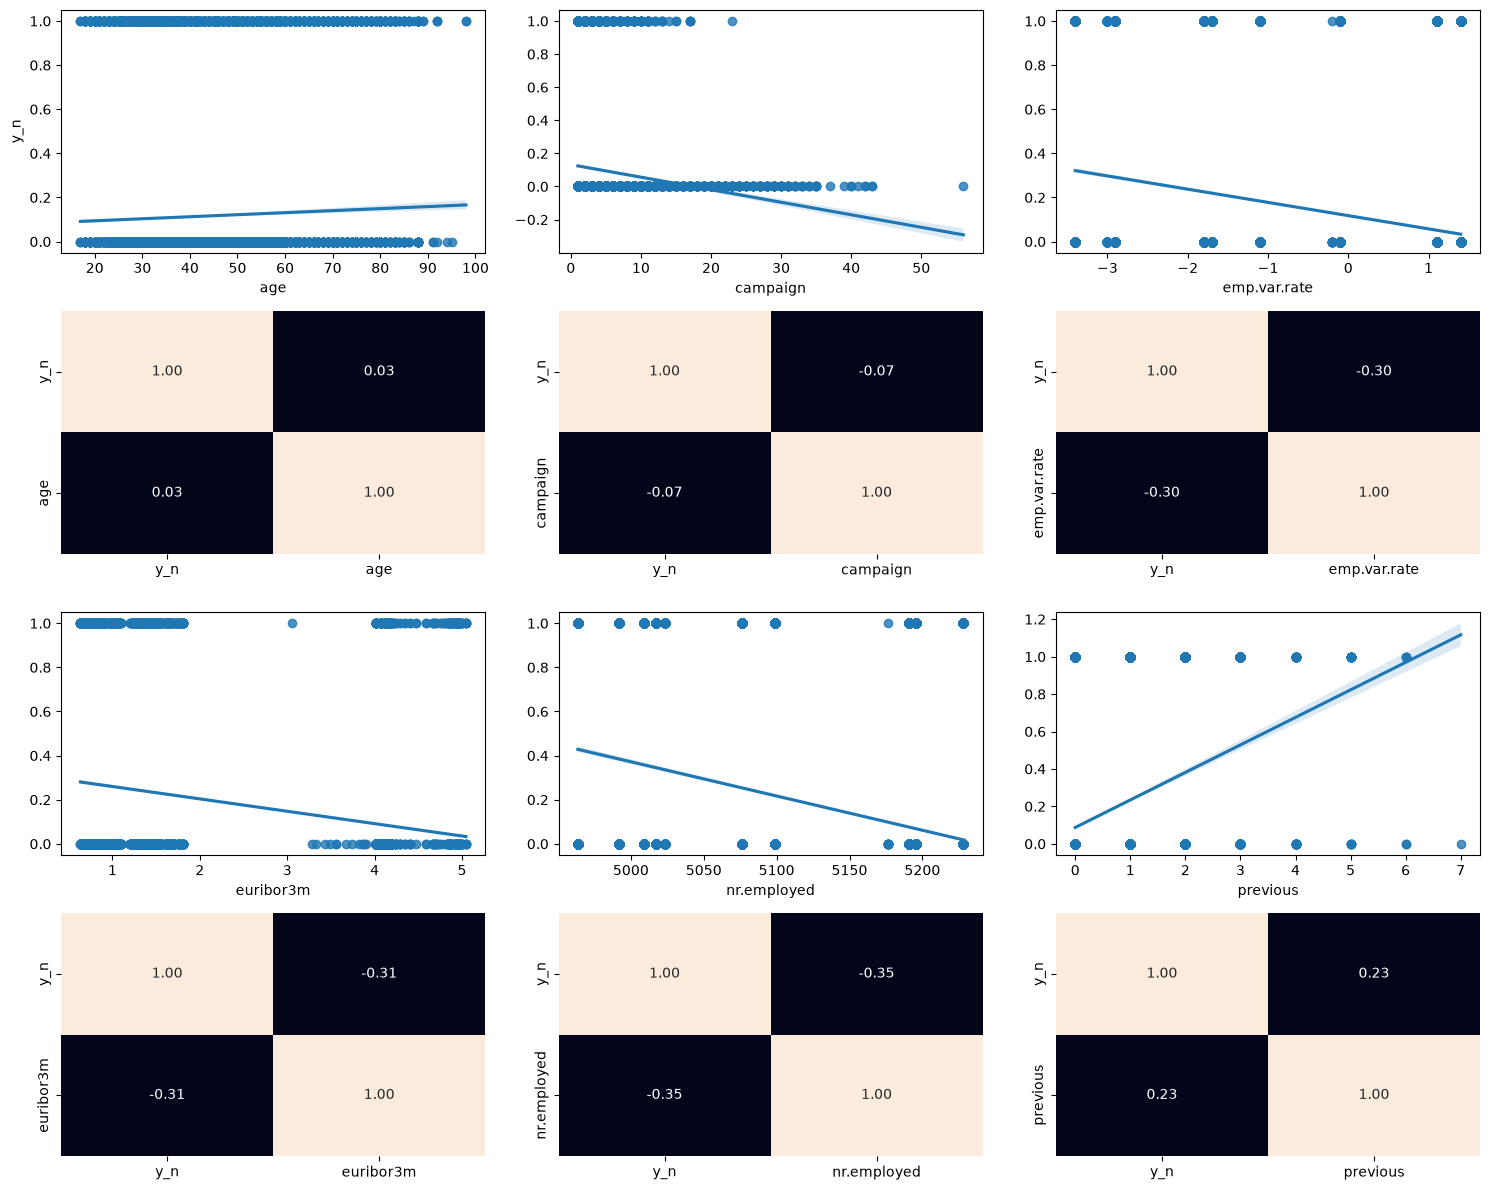

In [14]:
fig, axis = plt.subplots(4, 3, figsize = (15, 12))

# Crear un diagrama de dispersión múltiple
sns.regplot(ax = axis[0, 0], data = total_data, x = "age", y = "y_n")
sns.heatmap(total_data[["y_n", "age"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)
sns.regplot(ax = axis[0, 1], data = total_data, x = "campaign", y = "y_n").set(ylabel=None)
sns.heatmap(total_data[["y_n", "campaign"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1], cbar = False)
sns.regplot(ax=axis[0, 2], data = total_data, x="emp.var.rate", y="y_n").set(ylabel=None)
sns.heatmap(total_data[["y_n", "emp.var.rate"]].corr(),annot=True,fmt=".2f",ax=axis[1, 2],cbar=False,)
sns.regplot(ax=axis[2, 0], data = total_data, x="euribor3m", y="y_n").set(ylabel=None)
sns.heatmap(total_data[["y_n", "euribor3m"]].corr(),annot=True,fmt=".2f",ax=axis[3, 0],cbar=False,)
sns.regplot(ax=axis[2, 1], data = total_data, x="nr.employed", y="y_n").set(ylabel=None)
sns.heatmap(total_data[["y_n", "nr.employed"]].corr(),annot=True,fmt=".2f",ax=axis[3, 1],cbar=False,)
sns.regplot(ax=axis[2, 2], data = total_data, x="previous", y="y_n").set(ylabel=None)
sns.heatmap(total_data[["y_n", "previous"]].corr(),annot=True,fmt=".2f",ax=axis[3, 2],cbar=False,)

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

- Factores individuales como la edad del cliente (age) y la saturación operativa de llamadas en el momento (campaign) muestran una relación lineal prácticamente nula con la conversión. Esto demuestra que el éxito de la campaña no depende de llamar más veces al mismo cliente ni de segmentar por grupos de edad aislados.
- Los indicadores del entorno económico general (como el euribor3m, nr.employed y emp.var.rate) junto con el comportamiento previo del cliente (previous) son los verdaderos motores predictivos, mostrando correlaciones significativamente más altas que marcan patrones claros de propensión al depósito.

## Ahora veamos el análisis categórico - categórico

##### Y - (job, marital, education, housing, loan, poutcomes, contact, month, default)

Primero analizamos la clase frente a las características categóricas, una a una. Aquí no habrá combinaciones de varias predictoras y la clase:

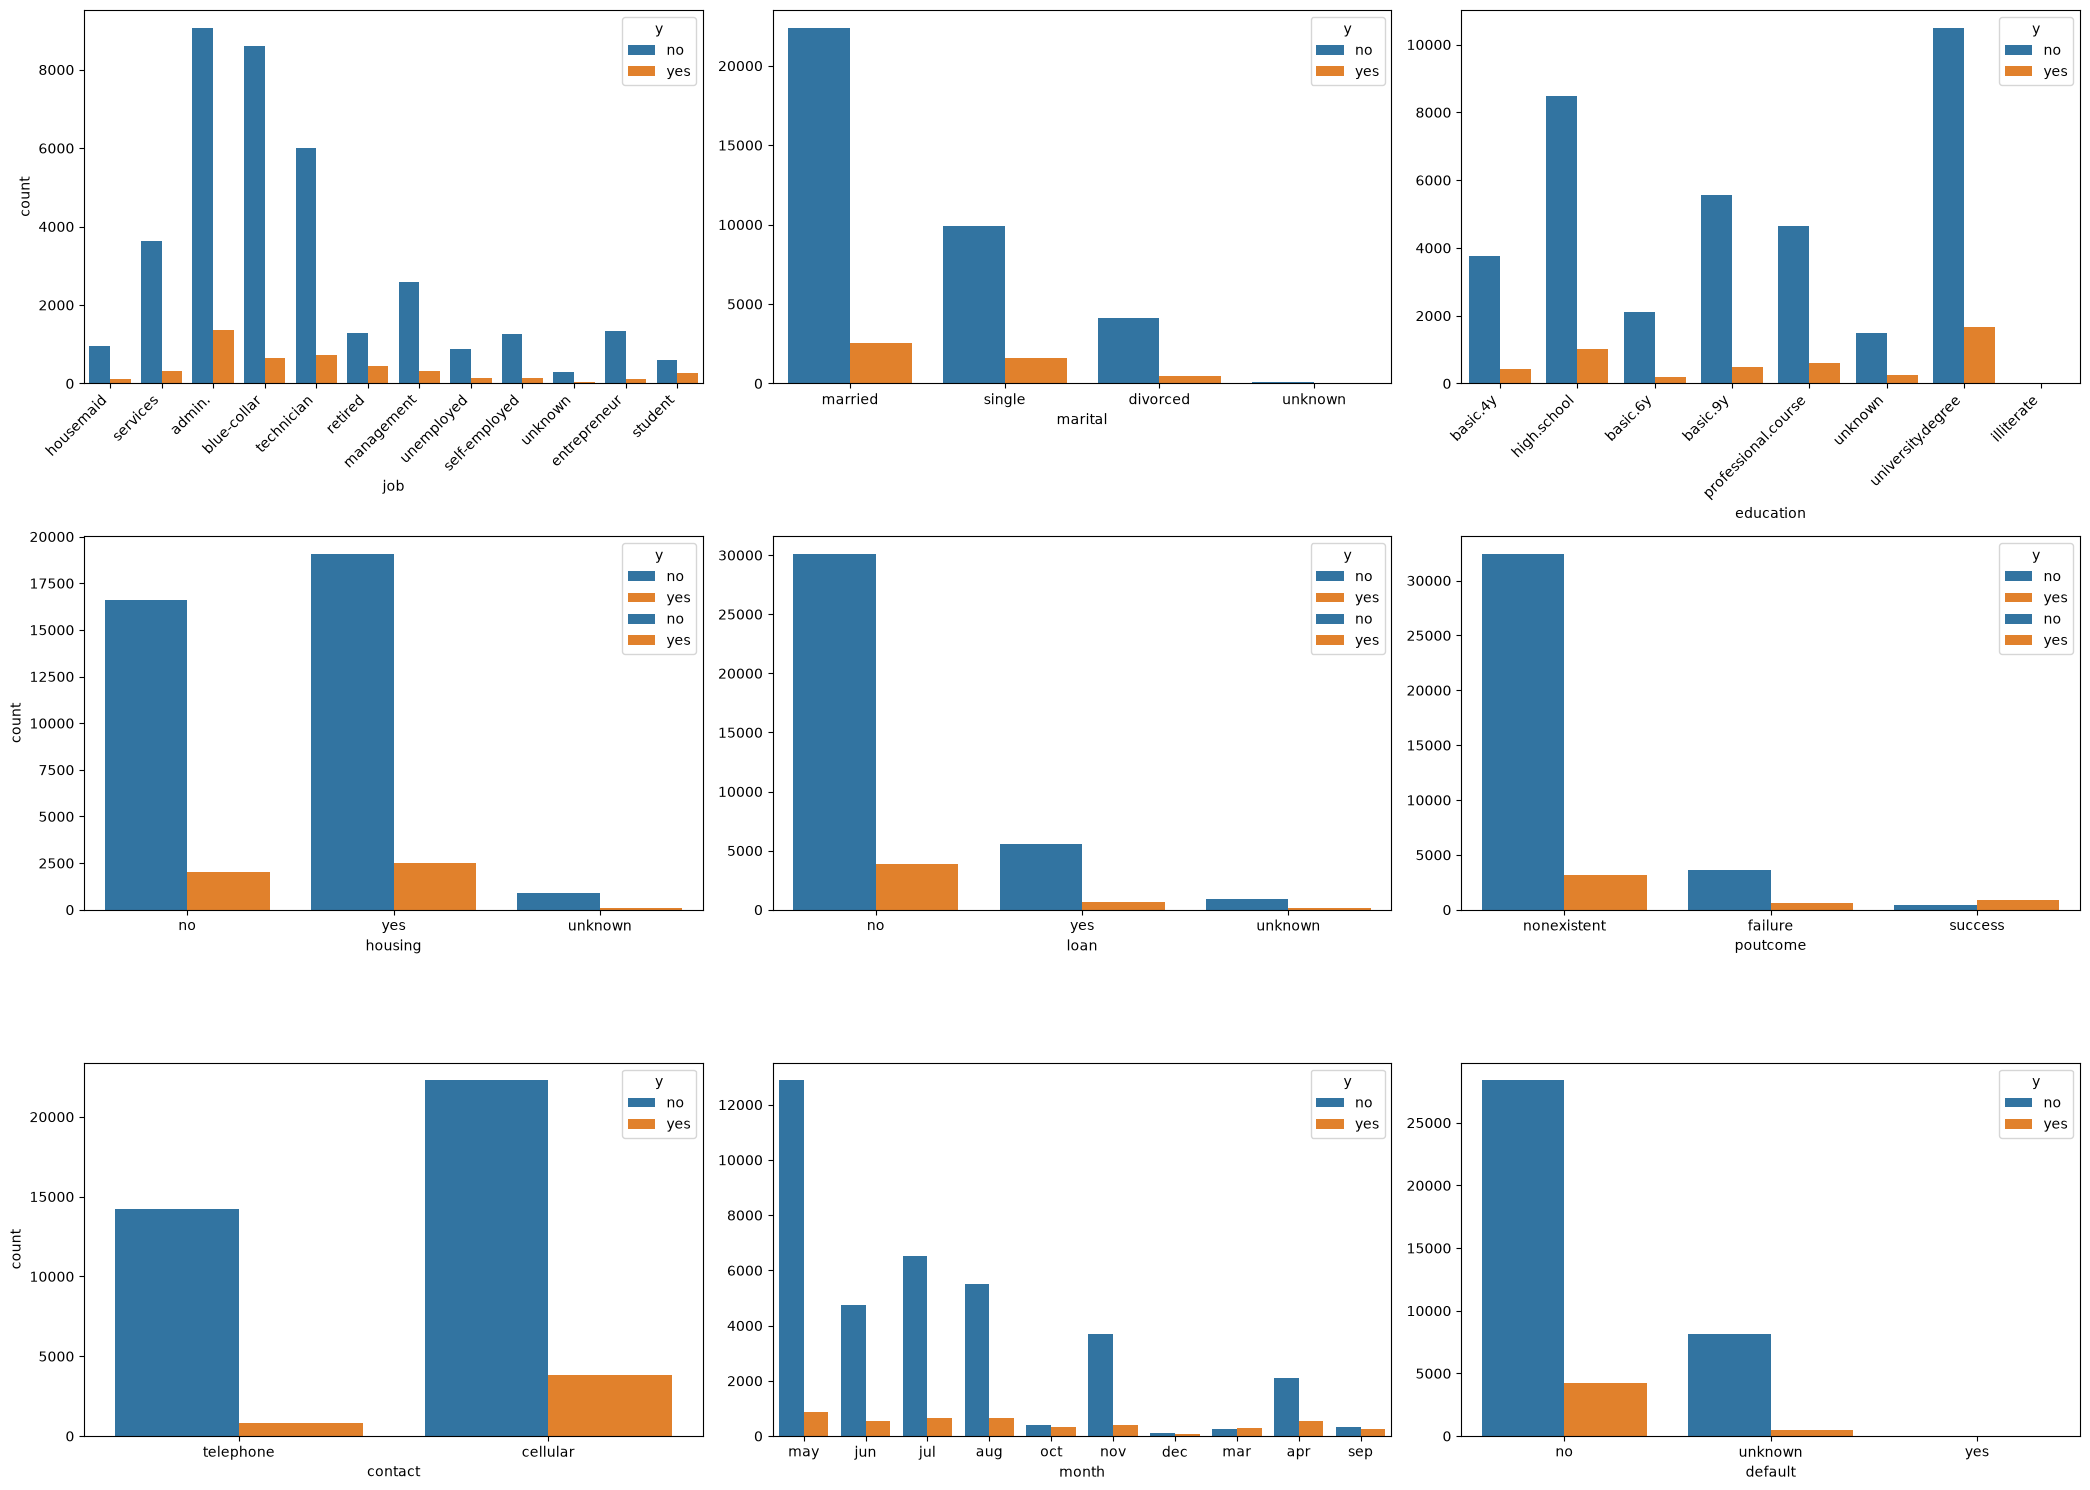

In [15]:
fig, axis = plt.subplots(3, 3, figsize = (21, 15))

sns.countplot(ax = axis[0, 0], data = total_data, x = "job", hue = "y")
sns.countplot(ax = axis[0, 1], data = total_data, x = "marital", hue = "y").set(ylabel = None)
sns.countplot(ax = axis[0, 2], data = total_data, x = "education", hue = "y").set(ylabel = None)
sns.countplot(ax = axis[1, 0], data = total_data, x = "housing", hue = "y")
sns.countplot(ax = axis[1, 1], data = total_data, x = "loan", hue = "y").set(ylabel = None)
sns.countplot(ax = axis[1, 2], data = total_data, x = "poutcome", hue = "y").set(ylabel = None)
sns.countplot(ax = axis[1, 0], data = total_data, x = "housing", hue = "y")
sns.countplot(ax = axis[1, 1], data = total_data, x = "loan", hue = "y").set(ylabel = None)
sns.countplot(ax = axis[1, 2], data = total_data, x = "poutcome", hue = "y").set(ylabel = None)
sns.countplot(ax = axis[2, 0], data = total_data, x = "contact", hue = "y")
sns.countplot(ax = axis[2, 1], data = total_data, x = "month", hue = "y").set(ylabel = None)
sns.countplot(ax = axis[2, 2], data = total_data, x = "default", hue = "y").set(ylabel = None)

for ax in [axis[0, 0], axis[0, 2]]:
    ax.tick_params(axis='x', rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha('right')

plt.tight_layout()

plt.show()


- **Empleo (job):** Se observa que perfiles como los trabajadores administrativos (admin.) y técnicos (blue-collar, technician) concentran el mayor volumen total de contactos, pero la proporción de aceptación (yes) se mantiene relativamente distribuida entre las distintas ocupaciones, destacando ligeramente los jubilados (retired) y estudiantes (student) en proporción a su tamaño de muestra.

- **Estado civil (marital):** Las personas casadas (married) representan la inmensa mayoría de la base de datos y del volumen de rechazos, seguidas por los solteros (single). La proporción de éxito es proporcionalmente similar entre los diferentes estados civiles.

- **Nivel educativo (education):** Los clientes con educación secundaria (university.degree y high.school) concentran el mayor volumen de llamadas y de aceptaciones, mostrando que el nivel formativo medio-alto es el target principal de la campaña.

- **Préstamo hipotecario (housing):** Contar o no con una hipoteca no genera una diferencia drástica en la decisión de aceptar el depósito; hay una proporción considerable de clientes tanto con vivienda hipotecada como sin ella que declinan la oferta.

- **Préstamo personal (loan):** La gran mayoría de los clientes no tienen un préstamo personal activo (no), y la proporción de aceptación es baja en ambos grupos, indicando que este factor no es un diferenciador fuerte por sí solo.

- **Resultado anterior (poutcome):** Es la variable con el comportamiento más revelador. Aunque la categoría predominante es "no existente" (nonexistent), los clientes que en una campaña previa tuvieron un resultado exitoso (success) muestran una tasa de conversión altísima en proporción a su volumen, confirmando que el historial positivo anterior es el mejor indicador categórico de éxito.

- **Tipo de contacto (contact):** Muestra una diferencia importante en la efectividad del canal. Las llamadas realizadas a teléfonos móviles (cellular) concentran un volumen mucho mayor de respuestas positivas en comparación con los teléfonos fijos (telephone), lo que indica que el canal móvil es considerablemente más receptivo para este tipo de campañas.

- **Mes del último contacto (month):** Revela una fuerte estacionalidad en la campaña. Hay meses específicos (como mayo o los meses de verano/otoño según la serie) que concentran picos masivos de llamadas y de conversiones, mientras que otros meses tienen una actividad casi nula, lo que demuestra que el timing anual influye decisivamente en el resultado.

- **Incumplimiento de crédito previo (default):** La gran mayoría de los registros se concentran en las categorías de "no" o "desconocido" (unknown), con una presencia casi nula de clientes en morosidad declarada (yes). Esto ocurre porque los bancos suelen filtrar preventivamente a clientes con impagos graves, por lo que esta variable aporta poca variabilidad predictiva directa en este punto.

## Ahora realizaremos Combinaciones de la clase con varias predictoras

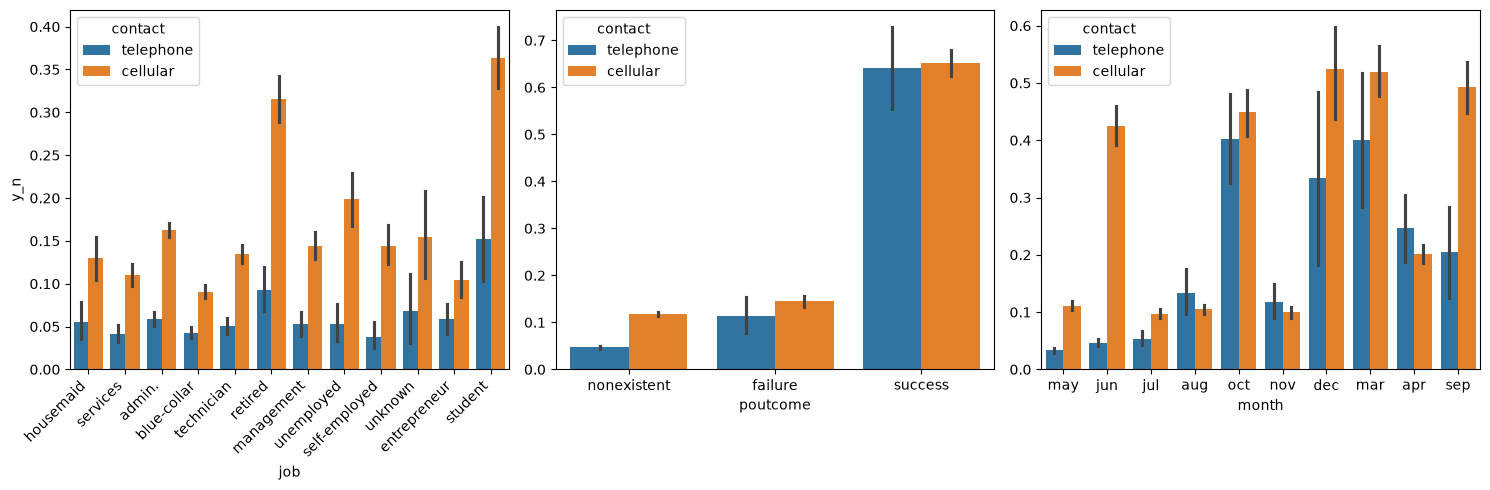

In [16]:
fig, axis = plt.subplots(figsize = (15, 5), ncols = 3)

sns.barplot(ax = axis[0], data = total_data, x = "job", y = "y_n", hue = "contact")
sns.barplot(ax = axis[1], data = total_data, x = "poutcome", y = "y_n", hue = "contact").set(ylabel = None)
sns.barplot(ax = axis[2], data = total_data, x = "month", y = "y_n", hue = "contact").set(ylabel = None)

for ax in [axis[0]]:
    ax.tick_params(axis='x', rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha('right')

plt.tight_layout()

plt.show()

- **Efectividad del canal móvil vs. fijo según el empleo (job):** El canal celular (cellular, representado por una de las barras) consistentemente muestra una tasa de conversión superior en casi todas las categorías profesionales en comparación con el teléfono fijo (telephone). Los trabajadores jubilados y estudiantes que son contactados por vía móvil registran los picos más altos de aceptación.

- **Impacto del historial previo combinado con el canal (poutcome):** Los clientes con un resultado previo de éxito (success) tienen una tasa de conversión extraordinariamente alta sin importar demasiado el canal, pero el uso del teléfono móvil maximiza aún más este éxito. Por el contrario, los clientes con historial desconocido o fracasado apenas varían su baja respuesta negativa, aunque el canal móvil sigue mostrando una ligera ventaja marginal.

- **Estacionalidad y canal de comunicación (month):** Se evidencia que los meses con mayor éxito en la campaña no solo dependen del momento del año, sino de que el canal celular estuvo hiperactivo o fue el medio predominante. En los meses donde la tasa de conversión se dispara, el uso del móvil marca una diferencia abismal frente al teléfono fijo, el cual mantiene tasas de éxito muy bajas o nulas a lo largo de los meses.

## Análisis de Correlaciones

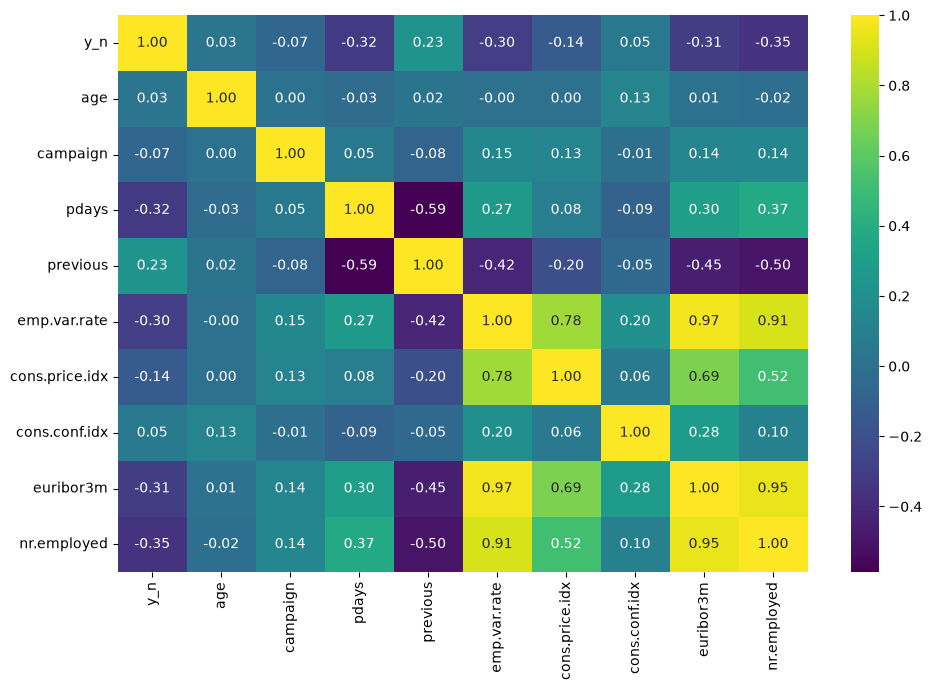

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

cols_num = ["y_n","age","campaign","pdays","previous","emp.var.rate","cons.price.idx","cons.conf.idx","euribor3m","nr.employed"]  # todas numéricas
fig, ax = plt.subplots(figsize=(10,7))
sns.heatmap(total_data[cols_num].corr(method="pearson"), annot=True, fmt=".2f", cmap="viridis", ax=ax)
plt.tight_layout()
plt.show()

## Ahora tenemos que factorizar el resto de las variables categoricas para poder agregarlas en la matriz de correlaciones.

In [18]:
total_data["job_n"] = pd.factorize(total_data.job)[0]
total_data[["job_n", "job"]]

,job_n,job
0,0,housemaid
1,1,services
2,1,services
3,2,admin.
4,1,services
...,...,...
41183,5,retired
41184,3,blue-collar
41185,5,retired
41186,4,technician


In [19]:
job_transformation_rules = {row["job"]: row["job_n"] for index, row in total_data[["job_n", "job"]].drop_duplicates().iterrows()}
with open("./job_transformation_rules.json", "w") as f:
  json.dump(job_transformation_rules, f)

In [20]:
total_data["marital_n"] = pd.factorize(total_data.marital)[0]
total_data[["marital_n", "marital"]]

,marital_n,marital
0,0,married
1,0,married
2,0,married
3,0,married
4,0,married
...,...,...
41183,0,married
41184,0,married
41185,0,married
41186,0,married


In [21]:
marital_transformation_rules = {row["marital"]: row["marital_n"] for index, row in total_data[["marital_n", "marital"]].drop_duplicates().iterrows()}
with open("./marital_transformation_rules.json", "w") as f:
  json.dump(marital_transformation_rules, f)

In [22]:
total_data["education_n"] = pd.factorize(total_data.education)[0]
total_data[["education_n", "education"]]

,education_n,education
0,0,basic.4y
1,1,high.school
2,1,high.school
3,2,basic.6y
4,1,high.school
...,...,...
41183,4,professional.course
41184,4,professional.course
41185,6,university.degree
41186,4,professional.course


In [23]:
education_transformation_rules = {row["education"]: row["education_n"] for index, row in total_data[["education_n", "education"]].drop_duplicates().iterrows()}
with open("./education_transformation_rules.json", "w") as f:
  json.dump(education_transformation_rules, f)

In [24]:
total_data["default_n"] = pd.factorize(total_data.default)[0]


In [25]:
default_transformation_rules = {row["default"]: row["default_n"] for index, row in total_data[["default_n", "default"]].drop_duplicates().iterrows()}
with open("./default_transformation_rules.json", "w") as f:
  json.dump(default_transformation_rules, f)

In [26]:
total_data["housing_n"] = pd.factorize(total_data.housing)[0]

In [27]:
housing_transformation_rules = {row["housing"]: row["housing_n"] for index, row in total_data[["housing_n", "housing"]].drop_duplicates().iterrows()}
with open("./housing_transformation_rules.json", "w") as f:
  json.dump(housing_transformation_rules, f)

In [28]:
total_data["loan_n"] = pd.factorize(total_data.loan)[0]

In [29]:
loan_transformation_rules = {row["loan"]: row["loan_n"] for index, row in total_data[["loan_n", "loan"]].drop_duplicates().iterrows()}
with open("./loan_transformation_rules.json", "w") as f:
  json.dump(loan_transformation_rules, f)

In [30]:
total_data["contact_n"] = pd.factorize(total_data.contact)[0]

In [31]:
contact_transformation_rules = {row["contact"]: row["contact_n"] for index, row in total_data[["contact_n", "contact"]].drop_duplicates().iterrows()}
with open("./contact_transformation_rules.json", "w") as f:
  json.dump(contact_transformation_rules, f)

In [32]:
total_data["month_n"] = pd.factorize(total_data.month)[0]

month_transformation_rules = {row["month"]: row["month_n"] for index, row in total_data[["month_n", "month"]].drop_duplicates().iterrows()}
with open("./month_transformation_rules.json", "w") as f:
  json.dump(month_transformation_rules, f)

In [33]:
total_data["day_of_week_n"] = pd.factorize(total_data.day_of_week)[0]

day_of_week_transformation_rules = {row["day_of_week"]: row["day_of_week_n"] for index, row in total_data[["day_of_week_n", "day_of_week"]].drop_duplicates().iterrows()}
with open("./day_of_week_transformation_rules.json", "w") as f:
  json.dump(day_of_week_transformation_rules, f)

In [34]:
total_data["poutcome_n"] = pd.factorize(total_data.poutcome)[0]

poutcome_transformation_rules = {row["poutcome"]: row["poutcome_n"] for index, row in total_data[["poutcome_n", "poutcome"]].drop_duplicates().iterrows()}
with open("./poutcome_transformation_rules.json", "w") as f:
  json.dump(poutcome_transformation_rules, f)

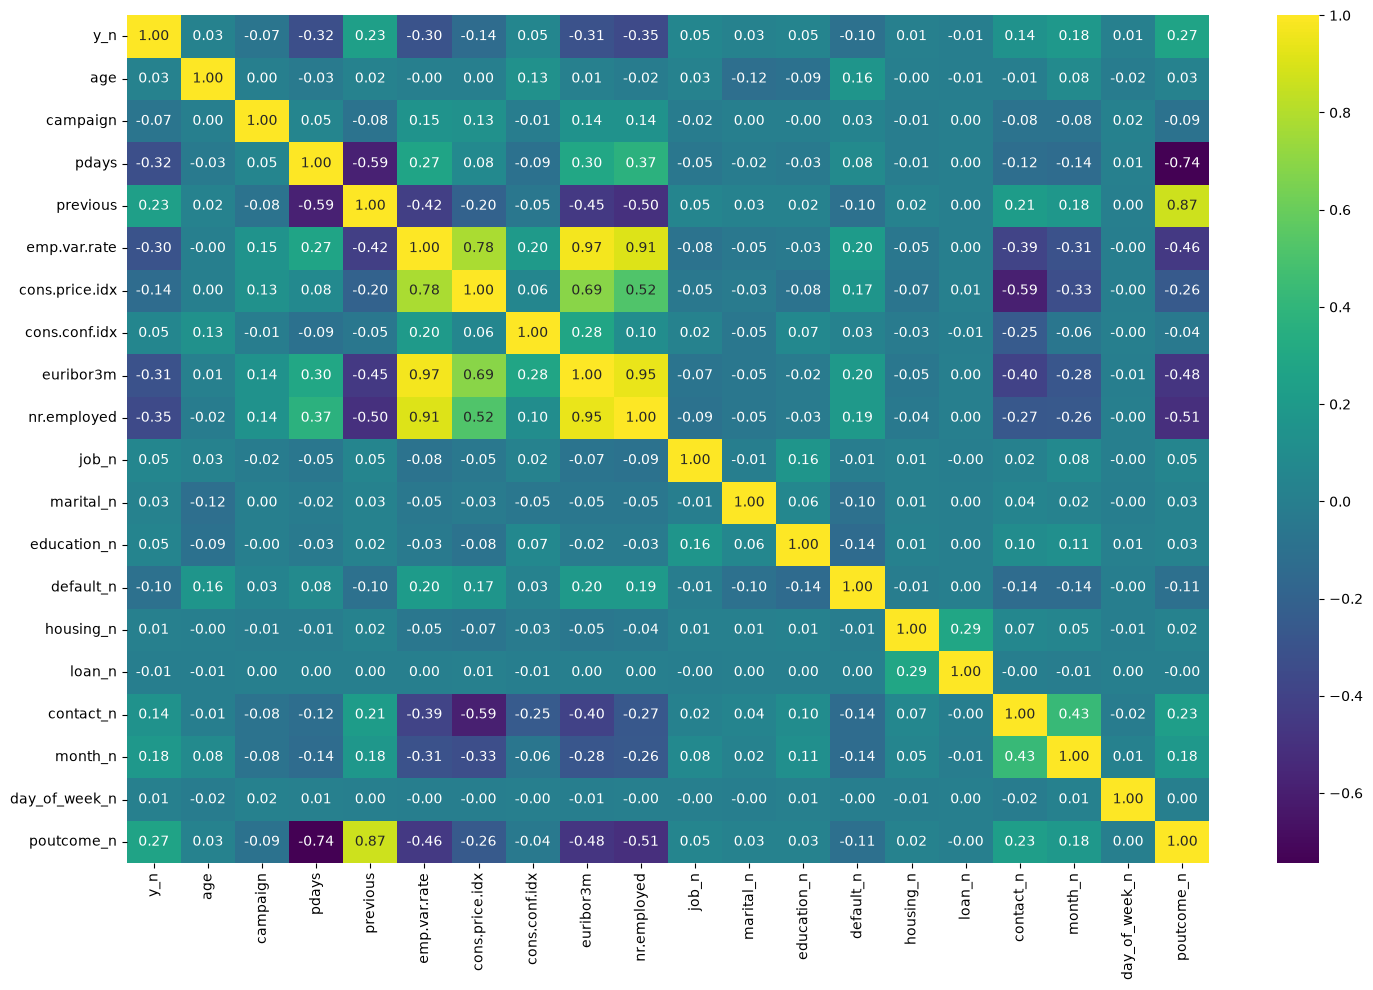

In [35]:
cols_num = ["y_n","age","campaign","pdays","previous","emp.var.rate","cons.price.idx","cons.conf.idx","euribor3m","nr.employed","job_n","marital_n","education_n","default_n","housing_n","loan_n","contact_n","month_n","day_of_week_n","poutcome_n"]  # todas numéricas
fig, ax = plt.subplots(figsize=(15,10))
sns.heatmap(total_data[cols_num].corr(method="pearson"), annot=True, fmt=".2f", cmap="viridis", ax=ax)
plt.tight_layout()
plt.show()

## Ingeniería de Características:

Análisis de Outliers:

In [36]:
total_data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous',
       'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m', 'nr.employed', 'y', 'y_n', 'job_n', 'marital_n',
       'education_n', 'default_n', 'housing_n', 'loan_n', 'contact_n',
       'month_n', 'day_of_week_n', 'poutcome_n'],
      dtype='str')

In [37]:
FINAL_COLS = ["y_n","age","campaign","pdays","previous","emp.var.rate","cons.price.idx","cons.conf.idx","euribor3m","nr.employed","job_n","marital_n","education_n","default_n","housing_n","loan_n","contact_n","month_n","day_of_week_n","poutcome_n"]
total_data = total_data[FINAL_COLS]

In [38]:
total_data.columns

Index(['y_n', 'age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'job_n',
       'marital_n', 'education_n', 'default_n', 'housing_n', 'loan_n',
       'contact_n', 'month_n', 'day_of_week_n', 'poutcome_n'],
      dtype='str')

In [39]:
total_data.describe()

,y_n,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_n,marital_n,education_n,default_n,housing_n,loan_n,contact_n,month_n,day_of_week_n,poutcome_n
count,41176.000000,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,0.112663,40.02380,2.567879,962.464810,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870,3.673863,0.510637,3.277370,0.208908,0.571959,0.199825,0.634714,2.249951,1.979600,0.169953
std,0.316184,10.42068,2.770318,186.937102,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364,2.454340,0.696794,2.185558,0.406713,0.541216,0.456055,0.481516,2.429157,1.411539,0.455811
min,0.000000,17.00000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,32.00000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,0.000000,38.00000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,3.000000,0.000000,3.000000,0.000000,1.000000,0.000000,1.000000,2.000000,2.000000,0.000000
75%,0.000000,47.00000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,4.000000,1.000000,6.000000,0.000000,1.000000,0.000000,1.000000,3.000000,3.000000,0.000000
max,1.000000,98.00000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,11.000000,3.000000,7.000000,2.000000,2.000000,2.000000,1.000000,9.000000,4.000000,2.000000


## Vamos a considerar sólo las variables numericas reales + la variable objetivo

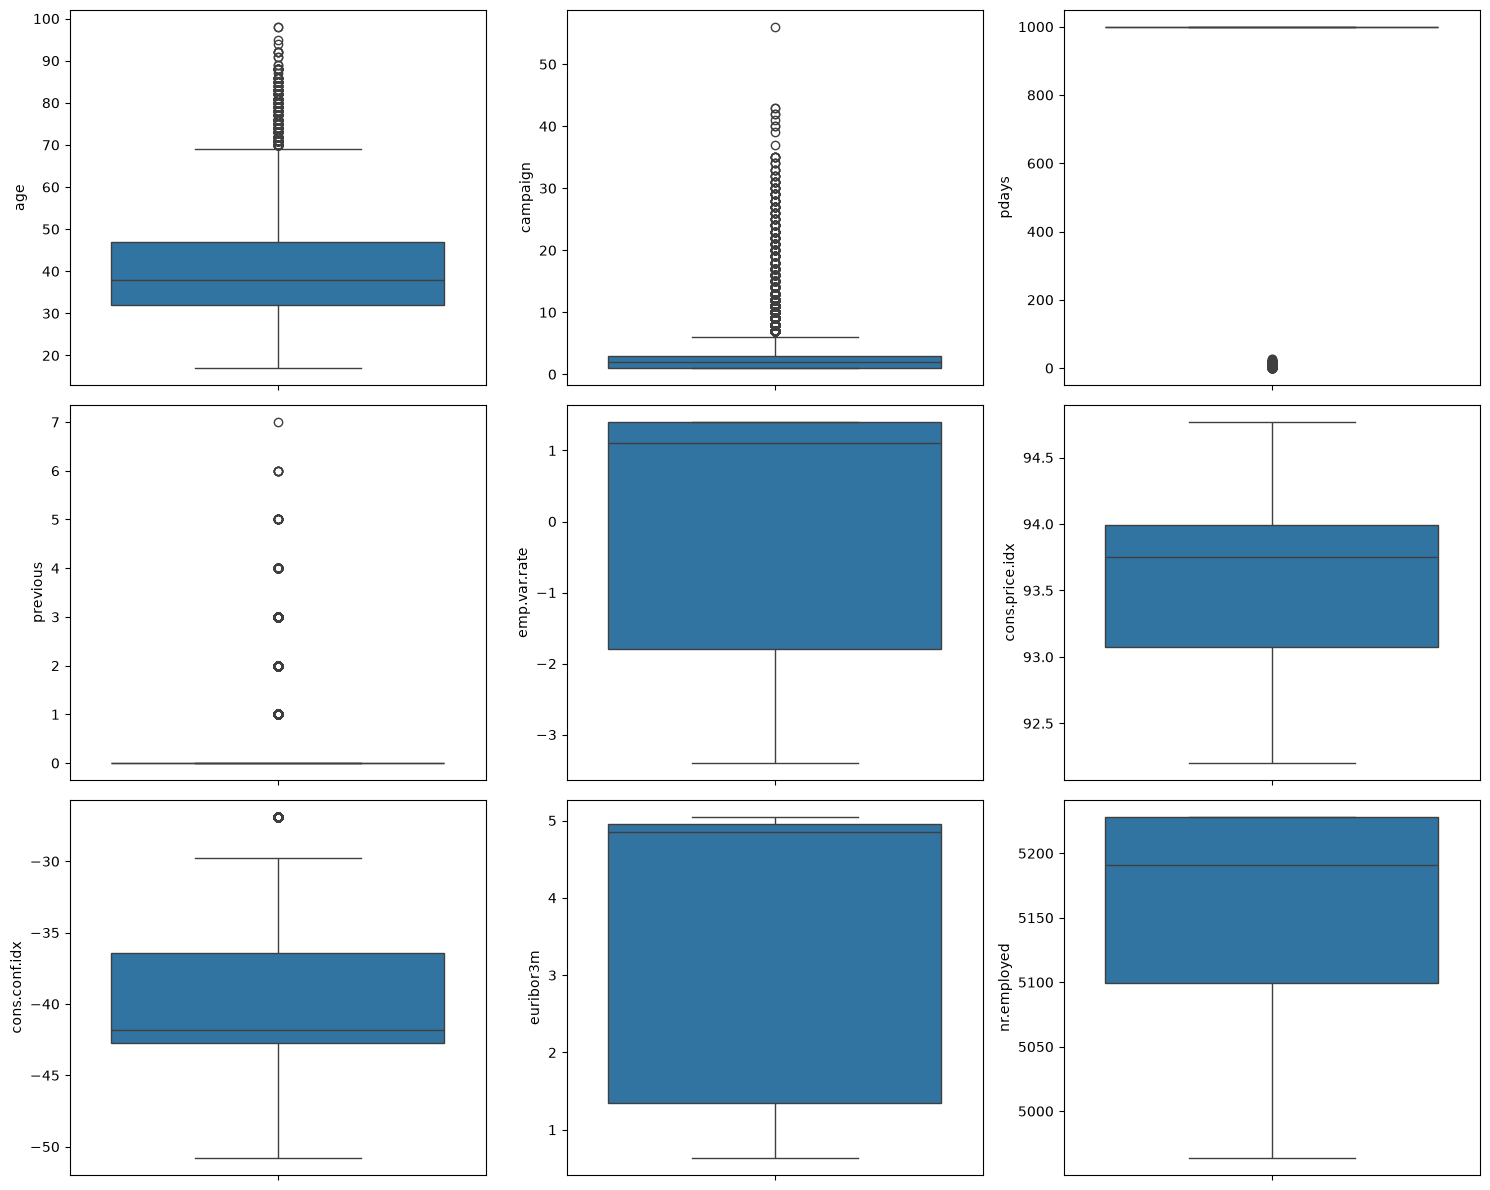

In [40]:
fig, axis = plt.subplots(3, 3, figsize = (15, 12))

sns.boxplot(ax = axis[0, 0], data = total_data, y = "age")
sns.boxplot(ax = axis[0, 1], data = total_data, y = "campaign")
sns.boxplot(ax = axis[0, 2], data = total_data, y = "pdays")
sns.boxplot(ax = axis[1, 0], data = total_data, y = "previous")
sns.boxplot(ax = axis[1, 1], data = total_data, y = "emp.var.rate")
sns.boxplot(ax = axis[1, 2], data = total_data, y = "cons.price.idx")
sns.boxplot(ax = axis[2, 0], data = total_data, y = "cons.conf.idx")
sns.boxplot(ax = axis[2, 1], data = total_data, y = "euribor3m")
sns.boxplot(ax = axis[2, 2], data = total_data, y = "nr.employed")



plt.tight_layout()

plt.show()

### Variables con presencia de valores atípicos (Outliers):
El análisis mediante diagramas de caja evidencia que variables como la edad (age) concentran su distribución central de forma habitual, pero registran valores atípicos hacia el extremo superior que superan los 70 a 85 años, representando a clientes de la tercera edad que deben conservarse al aportar información demográfica valiosa. De igual manera, el número de contactos en la campaña actual (campaign) y los contactos previos (previous) presentan colas de valores atípicos marcadas (llegando a más de 20-50 llamadas en la campaña actual y hasta 7 contactos previos), lo que permite identificar de forma clara los casos de sobre-contacto, saturación o un seguimiento comercial intensivo sobre ciertos perfiles de clientes.

### Variables sin valores atípicos aparentes:
Por otra parte, las variables macroeconómicas y los indicadores temporales del conjunto de datos —como la tasa de variación del empleo (emp.var.rate), el Euribor a 3 meses (euribor3m), el índice de precios al consumo (cons.price.idx), el índice de confianza del consumidor (cons.conf.idx) y el número de empleados (nr.employed)— muestran distribuciones estables agrupadas en bloques temporales específicos de la campaña. Estas métricas no reflejan anomalías aisladas, errores de marcación ni valores extremos fuera de los rangos económicos normales en los que operó la entidad financiera durante los periodos evaluados.

In [41]:
from numpy._core.defchararray import upper
# TENEMOS QUE GUARDARNOS TODOS LOS DATASETS, ES DECIR:

total_data_CON_outliers = total_data.copy()
total_data_SIN_outliers = total_data.copy() # Lo vamos a modificar. Para cada variable con outliers, reemplazamos sus valores outliers

outliers_cols = ["campaign"]

def replace_outliers(column, df):
  col_stats = total_data[column].describe()
  col_iqr = col_stats["75%"] - col_stats["25%"]
  upper_limit = round(float(col_stats["75%"] + 1.5 * col_iqr), 2)
  lower_limit = round(float(col_stats["25%"] - 1.5 * col_iqr), 2)

  if lower_limit < 0: lower_limit = min(df[column])
  # Vamos a quitar los outliers superiores
  df[column] = df[column].apply(lambda x: x if (x <= upper_limit) else upper_limit)
  # Vamos a quitar los outliers inferiores
  df[column] = df[column].apply(lambda x: x if (x >= lower_limit) else lower_limit)
  return df.copy(), [lower_limit, upper_limit]

outliers_dict = {}
for column in outliers_cols:
  total_data_SIN_outliers, limits = replace_outliers(column, total_data_SIN_outliers)
  outliers_dict.update({column: limits})

outliers_dict # Este JSON me lo tengo que GUARDAR

{'campaign': [1, 6.0]}

In [42]:
with open("./outliers_dict.json", "w") as f:
  json.dump(outliers_dict, f)

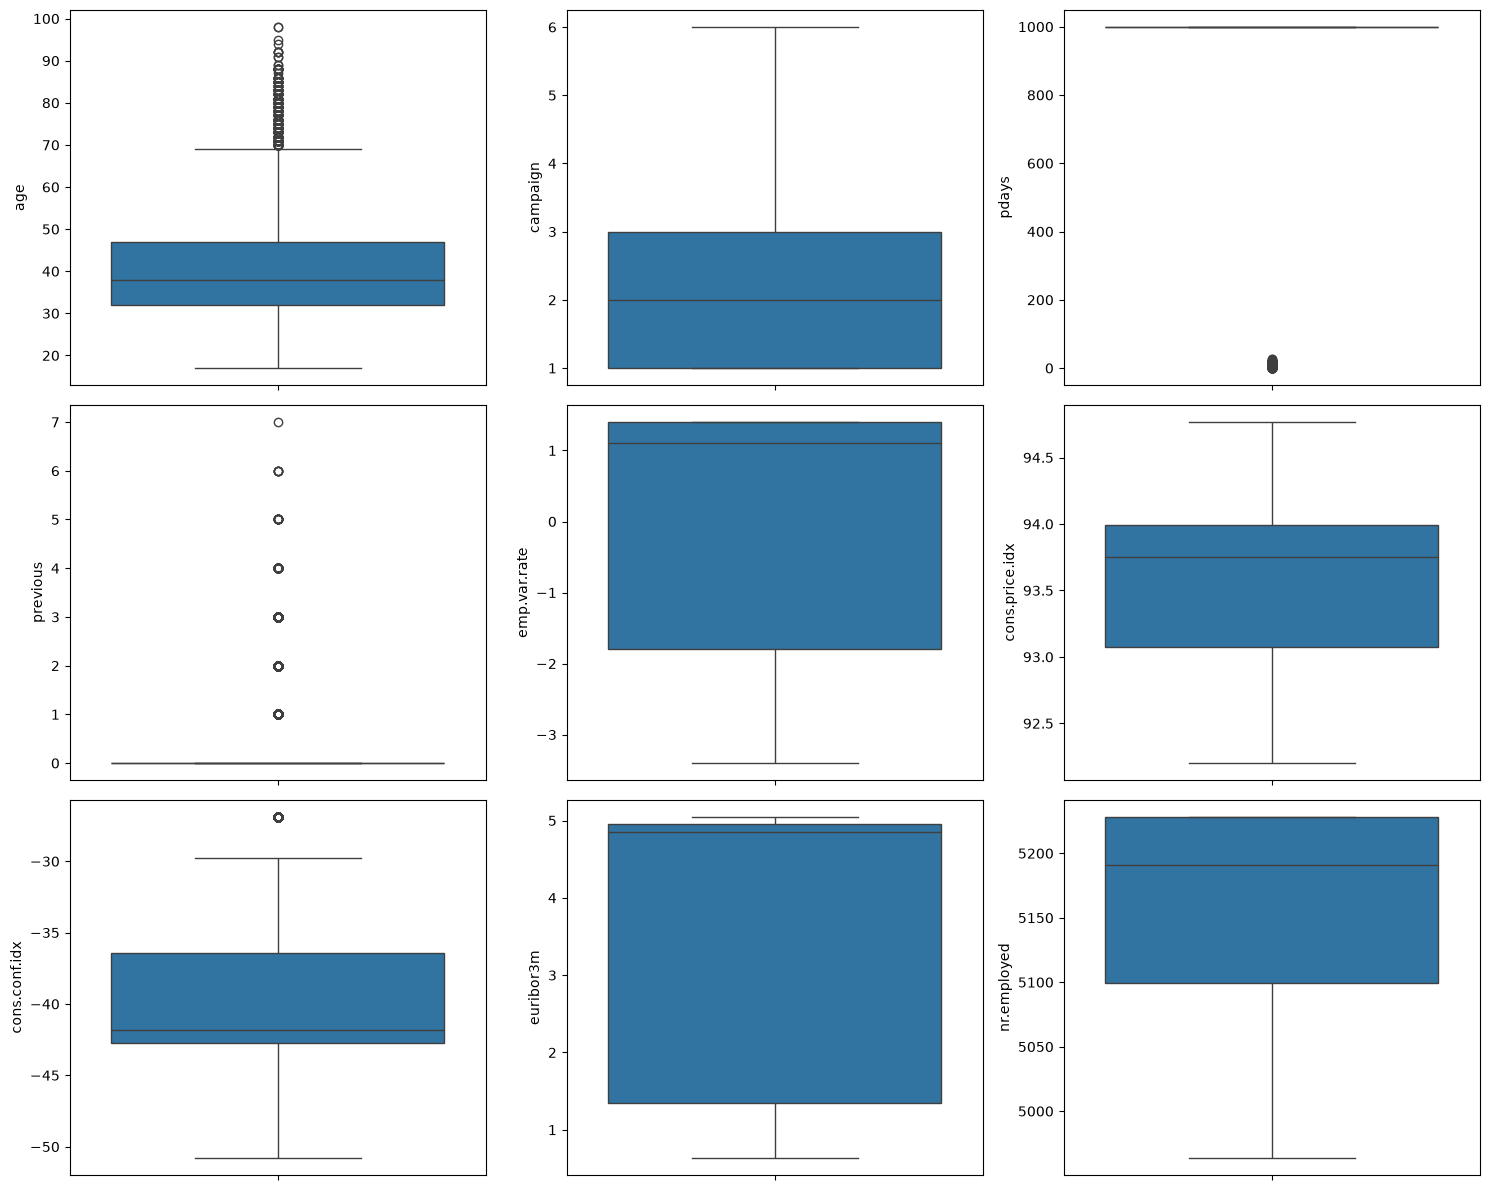

In [43]:
fig, axis = plt.subplots(3, 3, figsize = (15, 12))

sns.boxplot(ax = axis[0, 0], data = total_data_SIN_outliers, y = "age")
sns.boxplot(ax = axis[0, 1], data = total_data_SIN_outliers, y = "campaign")
sns.boxplot(ax = axis[0, 2], data = total_data_SIN_outliers, y = "pdays")
sns.boxplot(ax = axis[1, 0], data = total_data_SIN_outliers, y = "previous")
sns.boxplot(ax = axis[1, 1], data = total_data_SIN_outliers, y = "emp.var.rate")
sns.boxplot(ax = axis[1, 2], data = total_data_SIN_outliers, y = "cons.price.idx")
sns.boxplot(ax = axis[2, 0], data = total_data_SIN_outliers, y = "cons.conf.idx")
sns.boxplot(ax = axis[2, 1], data = total_data_SIN_outliers, y = "euribor3m")
sns.boxplot(ax = axis[2, 2], data = total_data_SIN_outliers, y = "nr.employed")



plt.tight_layout()

plt.show()

## Análisis de Valores Faltantes

In [44]:
total_data_CON_outliers.isnull().sum().sort_values(ascending=False)

y_n               0
age               0
campaign          0
pdays             0
previous          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
job_n             0
marital_n         0
education_n       0
default_n         0
housing_n         0
loan_n            0
contact_n         0
month_n           0
day_of_week_n     0
poutcome_n        0
dtype: int64

In [45]:
total_data_SIN_outliers.isnull().sum().sort_values(ascending=False)

y_n               0
age               0
campaign          0
pdays             0
previous          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
job_n             0
marital_n         0
education_n       0
default_n         0
housing_n         0
loan_n            0
contact_n         0
month_n           0
day_of_week_n     0
poutcome_n        0
dtype: int64

In [46]:
from sklearn.model_selection import train_test_split

# ESTO ES LO QUE ENTRA EN ESTE PASO
# total_data_SIN_outliers
# total_data_CON_outliers

predictoras = ["euribor3m", "emp.var.rate", "nr.employed", "poutcome_n", "pdays", "contact_n", "month_n", "campaign", "age", "previous"]
target = "y_n"

X_CON = total_data_CON_outliers.drop(target, axis = 1)[predictoras]
X_SIN = total_data_SIN_outliers.drop(target, axis = 1)[predictoras]
y = total_data_CON_outliers[target]

X_train_CON_outliers, X_test_CON_outliers, y_train, y_test = train_test_split(X_CON, y, test_size = 0.2, random_state = 10)
X_train_SIN_outliers, X_test_SIN_outliers = train_test_split(X_SIN, test_size = 0.2, random_state = 10)

# ESTO ES LO QUE SALE DE ESTE PASO
# X_train_CON_outliers
# X_test_CON_outliers
# X_train_SIN_outliers
# X_test_SIN_outliers
# y_train
# y_test

## Escalado de Valores:

In [47]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# ESTO ES LO QUE ENTRA EN ESTE PASO
# X_train_CON_outliers
# X_test_CON_outliers
# X_train_SIN_outliers
# X_test_SIN_outliers
# y_train
# y_test

## NORMALIZACIÓN (cambiar valores para que tengan media de 0 y std de 1)
### CON OUTLIERS
norm_CON_outliers = StandardScaler()
norm_CON_outliers.fit(X_train_CON_outliers)

X_train_CON_outliers_norm = norm_CON_outliers.transform(X_train_CON_outliers)
X_train_CON_outliers_norm = pd.DataFrame(X_train_CON_outliers_norm, index = X_train_CON_outliers.index, columns = predictoras)

X_test_CON_outliers_norm = norm_CON_outliers.transform(X_test_CON_outliers)
X_test_CON_outliers_norm = pd.DataFrame(X_test_CON_outliers_norm, index = X_test_CON_outliers.index, columns = predictoras)

### SIN OUTLIERS
norm_SIN_outliers = StandardScaler()
norm_SIN_outliers.fit(X_train_SIN_outliers)

X_train_SIN_outliers_norm = norm_SIN_outliers.transform(X_train_SIN_outliers)
X_train_SIN_outliers_norm = pd.DataFrame(X_train_SIN_outliers_norm, index = X_train_SIN_outliers.index, columns = predictoras)

X_test_SIN_outliers_norm = norm_SIN_outliers.transform(X_test_SIN_outliers)
X_test_SIN_outliers_norm = pd.DataFrame(X_test_SIN_outliers_norm, index = X_test_SIN_outliers.index, columns = predictoras)


## ESCALADO MIN-MAX (MINMAXIMIZACIÓN) (cambiar valores para que estén comprendidos entre 0 y 1)
### CON OUTLIERS
scaler_CON_outliers = MinMaxScaler()
scaler_CON_outliers.fit(X_train_CON_outliers)

X_train_CON_outliers_scal = scaler_CON_outliers.transform(X_train_CON_outliers)
X_train_CON_outliers_scal = pd.DataFrame(X_train_CON_outliers_scal, index = X_train_CON_outliers.index, columns = predictoras)

X_test_CON_outliers_scal = scaler_CON_outliers.transform(X_test_CON_outliers)
X_test_CON_outliers_scal = pd.DataFrame(X_test_CON_outliers_scal, index = X_test_CON_outliers.index, columns = predictoras)

### SIN OUTLIERS
scaler_SIN_outliers = MinMaxScaler()
scaler_SIN_outliers.fit(X_train_SIN_outliers)

X_train_SIN_outliers_scal = scaler_SIN_outliers.transform(X_train_SIN_outliers)
X_train_SIN_outliers_scal = pd.DataFrame(X_train_SIN_outliers_scal, index = X_train_SIN_outliers.index, columns = predictoras)

X_test_SIN_outliers_scal = scaler_SIN_outliers.transform(X_test_SIN_outliers)
X_test_SIN_outliers_scal = pd.DataFrame(X_test_SIN_outliers_scal, index = X_test_SIN_outliers.index, columns = predictoras)

# ESTO ES LO QUE SALE DE ESTE PASO
# X_train_CON_outliers
# X_train_CON_outliers_norm
# X_train_CON_outliers_scal
# X_train_SIN_outliers
# X_train_SIN_outliers_norm
# X_train_SIN_outliers_scal
# X_test_CON_outliers
# X_test_CON_outliers_norm
# X_test_CON_outliers_scal
# X_test_SIN_outliers
# X_test_SIN_outliers_norm
# X_test_SIN_outliers_scal
# y_train
# y_test

In [48]:
X_train_CON_outliers

,euribor3m,emp.var.rate,nr.employed,poutcome_n,pdays,contact_n,month_n,campaign,age,previous
36631,1.260,-2.9,5076.2,2,7,1,1,1,30,1
32870,1.299,-1.8,5099.1,0,999,1,0,1,36,0
6542,4.857,1.1,5191.0,0,999,0,0,2,36,0
40466,0.903,-1.7,4991.6,2,14,1,3,1,26,1
10156,4.958,1.4,5228.1,0,999,0,1,2,35,0
...,...,...,...,...,...,...,...,...,...,...
40071,0.810,-1.7,4991.6,0,999,1,2,2,25,0
28025,1.483,-1.8,5099.1,0,999,1,8,1,39,0
29208,1.405,-1.8,5099.1,0,999,1,8,1,41,0
40073,0.810,-1.7,4991.6,0,999,1,2,3,34,0


In [49]:
X_train_CON_outliers_norm

,euribor3m,emp.var.rate,nr.employed,poutcome_n,pdays,contact_n,month_n,campaign,age,previous
36631,-1.361240,-1.899984,-1.256631,4.004103,-5.082927,0.759842,-0.513264,-0.565282,-0.962041,1.654628
32870,-1.338751,-1.199073,-0.939659,-0.373651,0.196532,0.759842,-0.925025,-0.565282,-0.387476,-0.349175
6542,0.712953,0.648782,0.332381,-0.373651,0.196532,-1.316063,-0.925025,-0.205648,-0.387476,-0.349175
40466,-1.567103,-1.135354,-2.427627,4.004103,-5.045673,0.759842,0.310258,-0.565282,-1.345084,1.654628
10156,0.771195,0.839940,0.845903,-0.373651,0.196532,-1.316063,-0.513264,-0.205648,-0.483237,-0.349175
...,...,...,...,...,...,...,...,...,...,...
40071,-1.620731,-1.135354,-2.427627,-0.373651,0.196532,0.759842,-0.101503,-0.205648,-1.440845,-0.349175
28025,-1.232648,-1.199073,-0.939659,-0.373651,0.196532,0.759842,2.369063,-0.565282,-0.100194,-0.349175
29208,-1.277627,-1.199073,-0.939659,-0.373651,0.196532,0.759842,2.369063,-0.565282,0.091327,-0.349175
40073,-1.620731,-1.135354,-2.427627,-0.373651,0.196532,0.759842,-0.101503,0.153985,-0.578998,-0.349175


In [50]:
X_train_CON_outliers_scal

,euribor3m,emp.var.rate,nr.employed,poutcome_n,pdays,contact_n,month_n,campaign,age,previous
36631,0.141918,0.104167,0.425709,1.0,0.007007,1.0,0.111111,0.000000,0.160494,0.142857
32870,0.150759,0.333333,0.512287,0.0,1.000000,1.0,0.000000,0.000000,0.234568,0.000000
6542,0.957379,0.937500,0.859735,0.0,1.000000,0.0,0.000000,0.023810,0.234568,0.000000
40466,0.060984,0.354167,0.105860,1.0,0.014014,1.0,0.333333,0.000000,0.111111,0.142857
10156,0.980277,1.000000,1.000000,0.0,1.000000,0.0,0.111111,0.023810,0.222222,0.000000
...,...,...,...,...,...,...,...,...,...,...
40071,0.039900,0.354167,0.105860,0.0,1.000000,1.0,0.222222,0.023810,0.098765,0.000000
28025,0.192473,0.333333,0.512287,0.0,1.000000,1.0,0.888889,0.000000,0.271605,0.000000
29208,0.174790,0.333333,0.512287,0.0,1.000000,1.0,0.888889,0.000000,0.296296,0.000000
40073,0.039900,0.354167,0.105860,0.0,1.000000,1.0,0.222222,0.047619,0.209877,0.000000


In [51]:
# GUARDARLO -> TODO <-

# RECORDAR HABER GUARDADO LOS JSONS DE LA FACTORIZACIÓN

# PATH = "/data/processed"
PATH = '/workspaces/machine-learning-python-template/data/processed'
import os
os.makedirs(PATH, exist_ok=True)

# DATASETS QUE HE IDO ACUMULANDO EN LOS PASOS 4 Y 5
X_train_CON_outliers.to_excel(f"{PATH}/X_train_CON_outliers.xlsx", index = False)
X_train_CON_outliers_norm.to_excel(f"{PATH}/X_train_CON_outliers_norm.xlsx", index = False)
X_train_CON_outliers_scal.to_excel(f"{PATH}/X_train_CON_outliers_scal.xlsx", index = False)
X_train_SIN_outliers.to_excel(f"{PATH}/X_train_SIN_outliers.xlsx", index = False)
X_train_SIN_outliers_norm.to_excel(f"{PATH}/X_train_SIN_outliers_norm.xlsx", index = False)
X_train_SIN_outliers_scal.to_excel(f"{PATH}/X_train_SIN_outliers_scal.xlsx", index = False)

X_test_CON_outliers.to_excel(f"{PATH}/X_test_CON_outliers.xlsx", index = False)
X_test_CON_outliers_norm.to_excel(f"{PATH}/X_test_CON_outliers_norm.xlsx", index = False)
X_test_CON_outliers_scal.to_excel(f"{PATH}/X_test_CON_outliers_scal.xlsx", index = False)
X_test_SIN_outliers.to_excel(f"{PATH}/X_test_SIN_outliers.xlsx", index = False)
X_test_SIN_outliers_norm.to_excel(f"{PATH}/X_test_SIN_outliers_norm.xlsx", index = False)
X_test_SIN_outliers_scal.to_excel(f"{PATH}/X_test_SIN_outliers_scal.xlsx", index = False)

y_train.to_excel(f"{PATH}/y_train.xlsx", index = False)
y_test.to_excel(f"{PATH}/y_test.xlsx", index = False)

# SCALERS
import pickle
MODEL_PATH = '/workspaces/machine-learning-python-template/models'
os.makedirs(MODEL_PATH, exist_ok=True)

with open(f"{MODEL_PATH}/norm_CON_outliers.pkl", "wb") as file:
  pickle.dump(norm_CON_outliers, file)
with open(f"{MODEL_PATH}/norm_SIN_outliers.pkl", "wb") as file:
  pickle.dump(norm_SIN_outliers, file)
with open(f"{MODEL_PATH}/scaler_CON_outliers.pkl", "wb") as file:
  pickle.dump(scaler_CON_outliers, file)
with open(f"{MODEL_PATH}/scaler_SIN_outliers.pkl", "wb") as file:
  pickle.dump(scaler_SIN_outliers, file)


## Seleción de Caracteristicas:

In [52]:
from sklearn.feature_selection import f_classif, SelectKBest

X_train = X_train_CON_outliers.copy()
X_test = X_test_CON_outliers.copy()

# Con un valor de k = 5 
selection_model = SelectKBest(f_classif, k = 5)
selection_model.fit(X_train, y_train)

ix = selection_model.get_support()
X_train_sel = pd.DataFrame(selection_model.transform(X_train), columns = X_train.columns.values[ix])
X_test_sel = pd.DataFrame(selection_model.transform(X_test), columns = X_test.columns.values[ix])

X_train_sel.head()

,euribor3m,emp.var.rate,nr.employed,poutcome_n,pdays
0,1.260,-2.9,5076.2,2.0,7.0
1,1.299,-1.8,5099.1,0.0,999.0
2,4.857,1.1,5191.0,0.0,999.0
3,0.903,-1.7,4991.6,2.0,14.0
4,4.958,1.4,5228.1,0.0,999.0


### Machine Learning 

- Seleccionamos el mejor dataset

In [55]:
import pandas as pd

PATH = '/workspaces/machine-learning-python-template/data/processed/'

X_train_CON_outliers = pd.read_excel(f"{PATH}/X_train_CON_outliers.xlsx")
X_train_CON_outliers_norm = pd.read_excel(f"{PATH}/X_train_CON_outliers_norm.xlsx")
X_train_CON_outliers_scal = pd.read_excel(f"{PATH}/X_train_CON_outliers_scal.xlsx")
X_train_SIN_outliers = pd.read_excel(f"{PATH}/X_train_SIN_outliers.xlsx")
X_train_SIN_outliers_norm = pd.read_excel(f"{PATH}/X_train_SIN_outliers_norm.xlsx")
X_train_SIN_outliers_scal = pd.read_excel(f"{PATH}/X_train_SIN_outliers_scal.xlsx")

X_test_CON_outliers = pd.read_excel(f"{PATH}/X_test_CON_outliers.xlsx")
X_test_CON_outliers_norm = pd.read_excel(f"{PATH}/X_test_CON_outliers_norm.xlsx")
X_test_CON_outliers_scal = pd.read_excel(f"{PATH}/X_test_CON_outliers_scal.xlsx")
X_test_SIN_outliers = pd.read_excel(f"{PATH}/X_test_SIN_outliers.xlsx")
X_test_SIN_outliers_norm = pd.read_excel(f"{PATH}/X_test_SIN_outliers_norm.xlsx")
X_test_SIN_outliers_scal = pd.read_excel(f"{PATH}/X_test_SIN_outliers_scal.xlsx")

y_train = pd.read_excel(f"{PATH}/y_train.xlsx")
y_test = pd.read_excel(f"{PATH}/y_test.xlsx")

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")

datasets = [
    X_train_CON_outliers,
    X_train_CON_outliers_norm,
    X_train_CON_outliers_scal,
    X_train_SIN_outliers,
    X_train_SIN_outliers_norm,
    X_train_SIN_outliers_scal
]
test_datasets = [
    X_test_CON_outliers,
    X_test_CON_outliers_norm,
    X_test_CON_outliers_scal,
    X_test_SIN_outliers,
    X_test_SIN_outliers_norm,
    X_test_SIN_outliers_scal
]

# Añadimos los nombres correspondientes en el mismo orden exacto
dataset_names = [
    "X_train_CON_outliers",
    "X_train_CON_outliers_norm",
    "X_train_CON_outliers_scal",
    "X_train_SIN_outliers",
    "X_train_SIN_outliers_norm",
    "X_train_SIN_outliers_scal",
]

models = []
metrics = []
for dataset in datasets:
  model = LogisticRegression(random_state = 10) # Entrenar un modelo por defecto
  model.fit(dataset, y_train)
  y_pred = model.predict(dataset)
  metric = accuracy_score(y_train, y_pred)
  models.append(model)
  metrics.append(metric)

best_metric = max(metrics)
best_index = metrics.index(best_metric)
best_dataset = datasets[best_index]
best_test_dataset = test_datasets[best_index]
print(f"El mejor dataset es: {dataset_names[best_index]} con un Accuracy de:"f" {best_metric:.4f}")

El mejor dataset es: X_train_SIN_outliers_scal con un Accuracy de: 0.8979


- Calculamos métricas de test:

In [60]:
# 1. Calculamos el accuracy en test para el mejor modelo ya entrenado
best_model = models[best_index]
y_pred_test = best_model.predict(best_test_dataset)
test_accuracy = accuracy_score(y_test, y_pred_test)

# 2. Mostramos ambos resultados en la consola
print(f"El mejor dataset es: {dataset_names[best_index]}")
print(f"Accuracy en Train: {best_metric:.4f}")
print(f"Accuracy en Test:  {test_accuracy:.4f}")

El mejor dataset es: X_train_SIN_outliers_scal
Accuracy en Train: 0.8979
Accuracy en Test:  0.9025


- Veamos el resto de las métricas

In [61]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Realizamos las predicciones sobre el dataset de prueba ganador
y_pred_test = best_model.predict(best_test_dataset)

# 2. Calculamos la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred_test)
print("Matriz de Confusión:")
print(conf_matrix)
print("-" * 50)

# 3. Generamos el reporte completo con Precision, Recall y F1-Score
report = classification_report(y_test, y_pred_test)
print("Reporte de Clasificación:")
print(report)

Matriz de Confusión:
[[7242  120]
 [ 683  191]]
--------------------------------------------------
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.91      0.98      0.95      7362
           1       0.61      0.22      0.32       874

    accuracy                           0.90      8236
   macro avg       0.76      0.60      0.63      8236
weighted avg       0.88      0.90      0.88      8236



### Matriz de Confusión:

- **Verdaderos Negativos ($7242$):** Clases 0 que el modelo predijo correctamente como 0. El modelo es excelente identificando a quienes no van a aceptar el depósito.
- **Falsos Positivos ($120$):** Clases 0 que el modelo confundió y marcó como 1 (predijo que aceptarían, pero no era así). Son errores bajos, lo cual es bueno.
- **Falsos Negativos ($683$):** Clases 1 que el modelo pasó por alto y marcó como 0 (clientes que sí aceptaban el depósito, pero el modelo dijo que no). Este es el punto débil principal: está dejando escapar a la gran mayoría de clientes potenciales.
- **Verdaderos Positivos ($191$):** Clases 1 que el modelo identificó correctamente. De los 874 clientes reales que sí aceptaban, solo atinó a 191.

### El Reporte de Clasificación:

- **Clase 0 (No acepta el depósito - La clase mayoritaria):**
- Precision ($0.91$): Cuando el modelo predice que un cliente no va a aceptar, acierta un 91% de las veces.
- Recall ($0.98$): De todos los clientes que realmente no iban a aceptar, el modelo fue capaz de atrapar al 98%. Prácticamente no se le escapa ninguno de estos.
- F1-Score ($0.95$): Excelente, impulsado por el gran volumen de datos de esta clase.

- **Clase 1 (Sí acepta el depósito - La clase minoritaria y de verdadero interés comercial):** 
- Precision ($0.61$): Cuando el modelo se arriesga a decir "este cliente sí va a aceptar", acierta el 61% de las veces. No está mal. 
- Recall ($0.22$): ¡Aquí está el problema crítico! De todos los clientes que realmente querían el depósito (los 874 en total), el modelo solo logró capturar el 22%. Está ignorando al 78% de los compradores potenciales reales.
- F1-Score ($0.32$): Al ser una media armónica baja debido al mal recall, confirma que el rendimiento para esta clase es pobre.